# Netflix Data Analysis

This project is an exploratory data analysis of the Netflix Movies and TV Shows dataset.

The goal of this project is to understand the Netflix catalog using Python, pandas, matplotlib, and seaborn.

In this project, I will:

- load and inspect the Netflix dataset
- clean missing and inconsistent values
- convert date columns into the correct format
- analyze Movies and TV Shows distribution
- explore top countries, genres, ratings, and yearly trends
- create visualizations to support the analysis
- summarize the main findings from the dataset

In [1]:
## Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
## Load the Dataset

df = pd.read_csv("data/netflix_titles.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## First Look at the Dataset

I check the size of the dataset and basic information about the columns.

In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Data Cleaning

In this step, I clean the dataset before creating visualizations.

I will handle missing values, remove duplicates, and convert the `date_added` column to datetime format.

In [8]:
netflix = df.copy()

In [9]:
netflix.duplicated().sum()

np.int64(0)

In [10]:
netflix = netflix.drop_duplicates()

In [11]:
netflix["date_added"] = pd.to_datetime(netflix["date_added"], errors="coerce")

In [12]:
netflix["year_added"] = netflix["date_added"].dt.year

In [13]:
netflix["country"] = netflix["country"].fillna("Unknown")
netflix["director"] = netflix["director"].fillna("Unknown")
netflix["cast"] = netflix["cast"].fillna("Unknown")
netflix["rating"] = netflix["rating"].fillna("Unknown")
netflix["duration"] = netflix["duration"].fillna("Unknown")

In [14]:
netflix.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      98
dtype: int64

In [15]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


## Movies vs TV Shows

First, I compare the number of Movies and TV Shows in the dataset.

In [16]:
type_counts = netflix["type"].value_counts()

type_counts

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

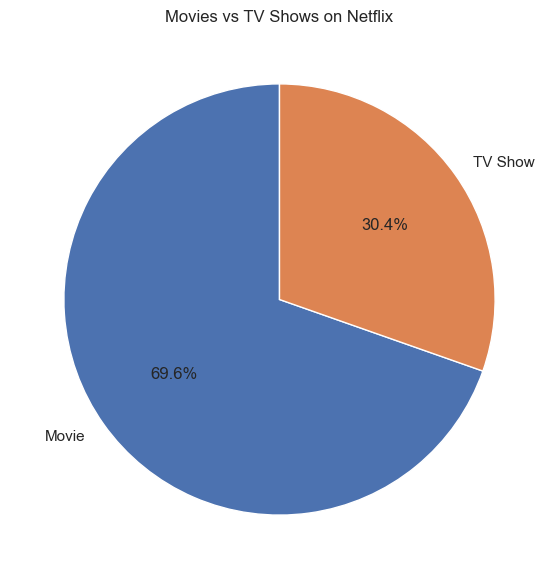

In [17]:
plt.figure(figsize=(7, 7))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Movies vs TV Shows on Netflix")
plt.show()

## Top 10 Countries by Content

Some titles have more than one country listed, so I split the country column before counting.

In [18]:
countries = netflix["country"].str.split(",").explode().str.strip()

In [19]:
top_countries = countries[countries != "Unknown"].value_counts().head(10)

top_countries

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

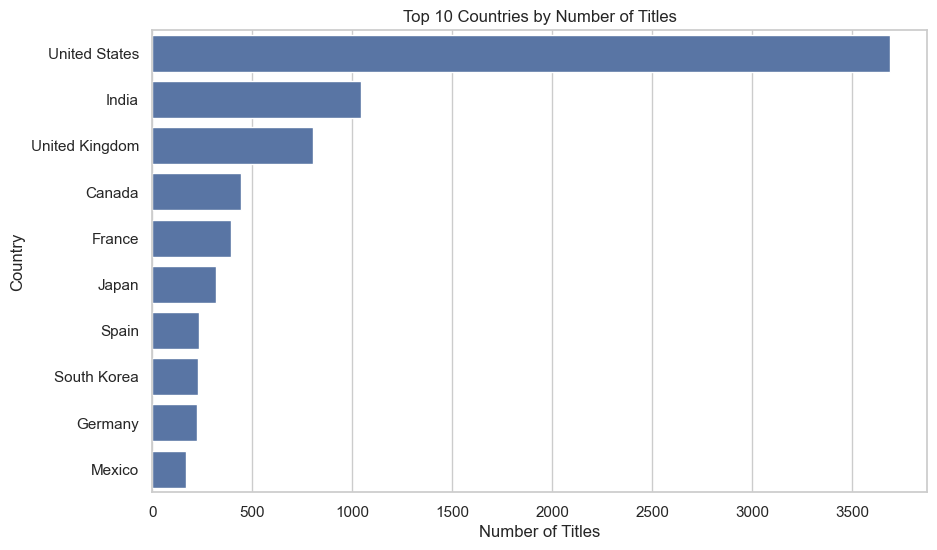

In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

## Content Added per Year

Now I check how many titles were added to Netflix each year.

In [21]:
content_by_year = netflix["year_added"].dropna().astype(int).value_counts().sort_index()

content_by_year

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
Name: count, dtype: int64

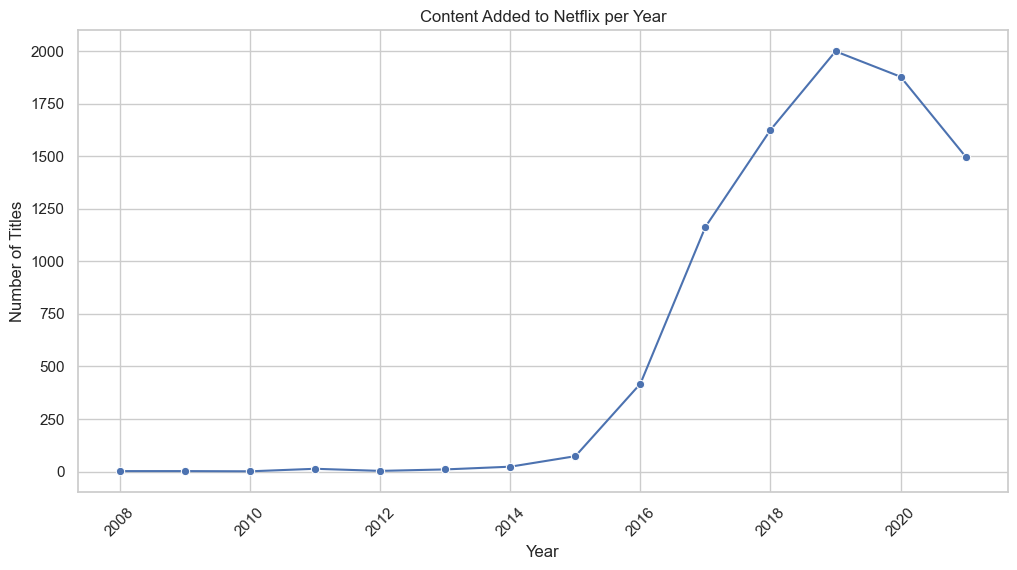

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=content_by_year.index,
    y=content_by_year.values,
    marker="o"
)

plt.title("Content Added to Netflix per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

## Top Genres

The genre information is stored in the `listed_in` column. I split this column to find the most common genres.

In [23]:
genres = netflix["listed_in"].str.split(",").explode().str.strip()

In [24]:
top_genres = genres.value_counts().head(10)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

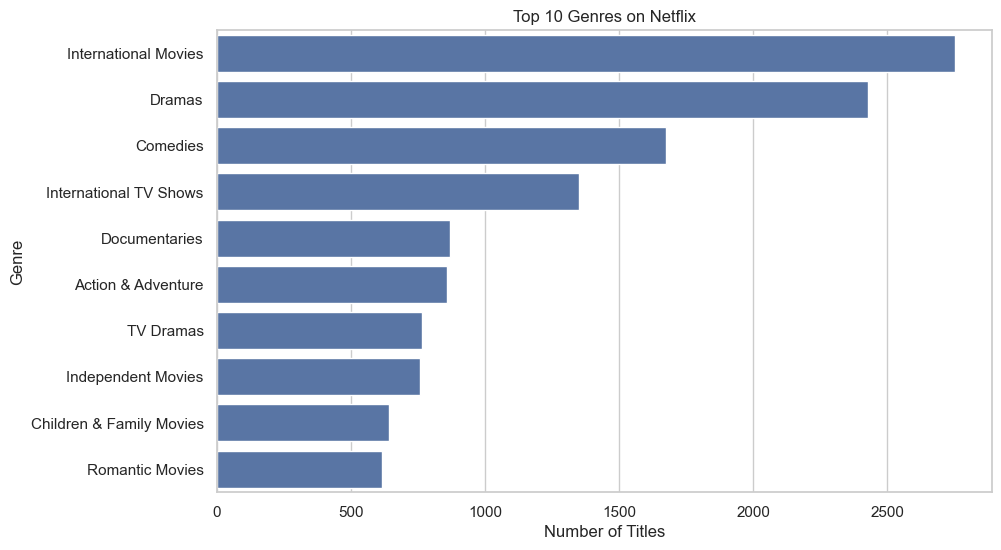

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

## Rating Distribution

Next, I check which content ratings are most common on Netflix.

In [26]:
rating_counts = netflix["rating"].value_counts()

rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

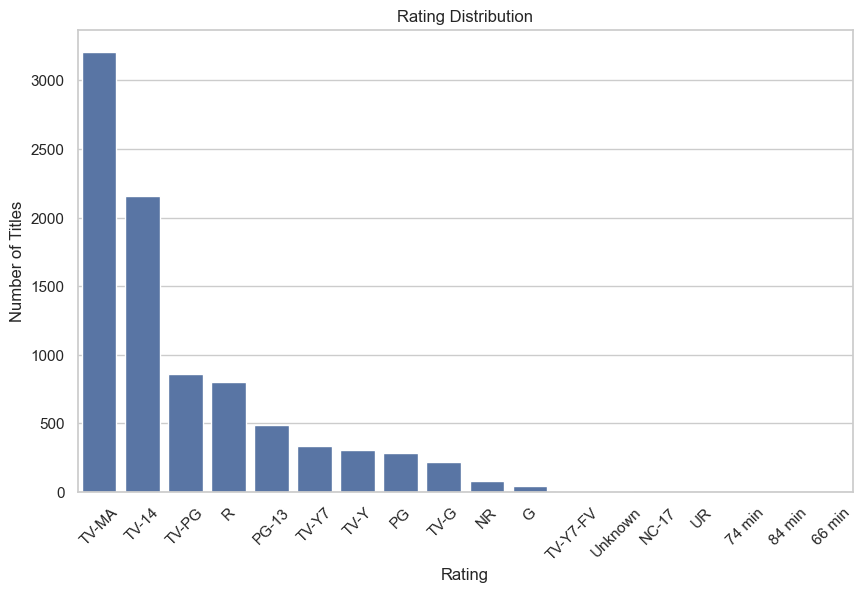

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

## Movies and TV Shows Added by Year

I also compare how Movies and TV Shows were added over time.

In [28]:
type_year = netflix.groupby(["year_added", "type"]).size().reset_index(name="count")

type_year.head()

,year_added,type,count
0,2008.0,Movie,1
1,2008.0,TV Show,1
2,2009.0,Movie,2
3,2010.0,Movie,1
4,2011.0,Movie,13


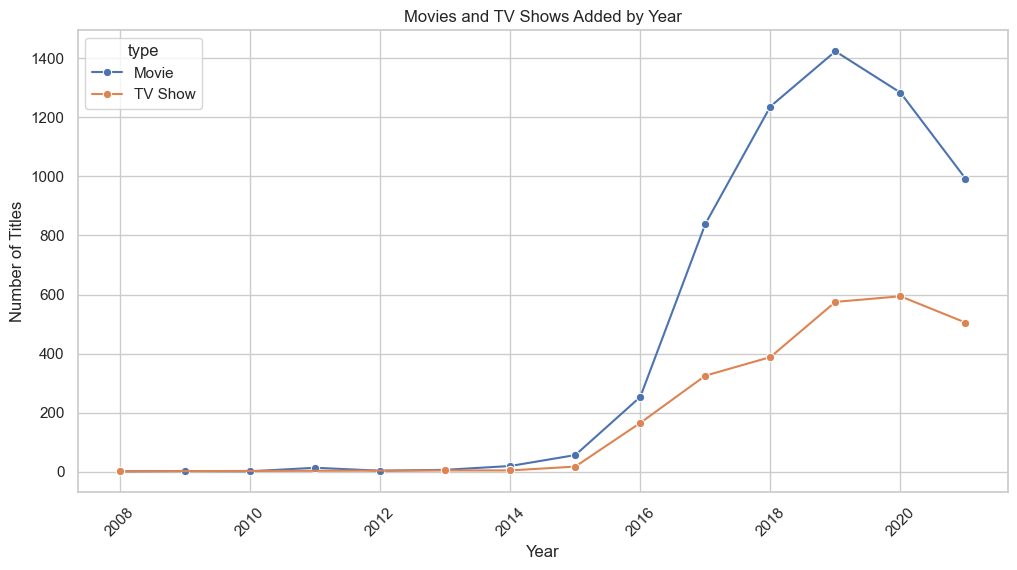

In [29]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=type_year,
    x="year_added",
    y="count",
    hue="type",
    marker="o"
)

plt.title("Movies and TV Shows Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

## Key Insights

1. Netflix has more Movies than TV Shows in this dataset.

2. The US is the top country by number of Netflix titles.

3. The number of titles added to Netflix increased strongly in the late 2010s.

4. International Movies, Dramas, and Comedies are among the most common content categories.

5. TV-MA and TV-14 are very common ratings, which shows that many titles are targeted toward teen and adult audiences.